## Importamos los módulos y datos

In [1]:
import pandas as pd
import hvplot.pandas
from datetime import datetime
from zoneinfo import ZoneInfo
import numpy as np
from func import procesa_datos

tzinfo_madrid = ZoneInfo("Europe/Madrid")

df = procesa_datos()
df["cls_spread_ida1_spot"] = np.where(df["spread_ida1_spot"] >=0, 1, -1)

C:\Users\Usuario\Desktop\Master UGR\TFM\src\func.py:160: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[:, "spread_ida1_spot"] = df["precio_spot_intradiario1_Espana"] - df["precio_spot_diario_Espana"]
C:\Users\Usuario\Desktop\Master UGR\TFM\src\func.py:161: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[:, "spread_ida2_spot"] = df["precio_spot_intradiario2_Espana"] - df["precio_spot_diario_Espana"]
C:\Users\Usuario\Desktop\Master UGR\TFM\src\func.py:162: PerformanceWarning: DataFrame is highly fragmented.  This is us

## Procesado de datos, feature eng., train y test.

In [2]:
## Creamos variables nuevas
from func import crear_lags_horarios
df = crear_lags_horarios(df, ["spread_ida1_spot", "precio_spot_diario_Espana", "precio_spot_intradiario1_Espana"], [24, 48, 72]).dropna()

## Fechas de entrenamiento, validación y test
train_from, train_to = datetime(2025, 11, 5, tzinfo=tzinfo_madrid),  datetime(2026, 2, 28, 23, 45, tzinfo=tzinfo_madrid)
test_from, test_to = datetime(2026, 4, 1, tzinfo=tzinfo_madrid), datetime(2026, 5, 31, 23, 45, tzinfo=tzinfo_madrid)

## columnas de entrenamiento
train_cols = [
    'dem_prev_diaria_6',
    'gen_prev_eolica_6',
    'gen_prev_fotov_6',
    'precio_spot_diario_Espana_lag_24h',
    'precio_spot_diario_Espana_lag_48h',
    'precio_spot_diario_Espana_lag_72h',
    'precio_spot_intradiario1_Espana_lag_24h',
    'precio_spot_intradiario1_Espana_lag_48h',
    'precio_spot_intradiario1_Espana_lag_72h',
    'spread_ida1_spot_lag_24h',
    'spread_ida1_spot_lag_48h',
    'spread_ida1_spot_lag_72h'
]
tgt_col = "spread_ida1_spot"
tgt_col_cls = "cls_spread_ida1_spot"

## dividimos los datasets reg
X_train, y_train = df.loc[train_from:train_to, train_cols], df.loc[train_from:train_to, tgt_col]
X_test, y_test =df.loc[test_from:test_to, train_cols], df.loc[test_from:test_to, tgt_col]

## dividimos los datasets reg
_, y_train_cls = df.loc[train_from:train_to, train_cols], df.loc[train_from:train_to, tgt_col_cls]
_, y_test_cls =df.loc[test_from:test_to, train_cols], df.loc[test_from:test_to, tgt_col_cls]

## Modelos y problema de optimización

Hay que hacer una predicción por día con su correspondiente problema de optimización

In [3]:
def optimizador(precios):
    return -np.sign(precios)

A continuación se detallan las pruebas que vamos a hacer:

- Regresión Ridge.
- Random Forest.
- Random Forest como problema de clasificación.
- CatBoost.
- Regresión lineal con la función de pérdida Tangente Hiperbólica.
- Regresión lineal con la función de pérdida Log-Sigmoid.
- Regresión lineal con la función de pérdida Exponencial PNL.
- CatBoost con la función de pérdida Tangente Hiperbólica.
- CatBoost con la función de pérdida Log-Sigmoid.
- CatBoost con la función de pérdida Exponencial PNL.
- SPO.

In [4]:
from func import get_ridge_model, get_rf_model, get_catboost_model, get_clsrf_model, get_lr_model
from pnl_custom_losses import  TanhPnLLoss, LogSigmoidPnLLoss, ExpoPnLLoss


reg_ridge = get_ridge_model()
rf = get_rf_model()
cls_rf = get_clsrf_model()
cb = get_catboost_model()
lr_tanh = get_lr_model(loss_function="TanhPnLLoss")
lr_logsigmoid = get_lr_model(loss_function="LogSigmoidPnLLoss")
lr_exp_pnl = get_lr_model(loss_function="ExpoPnLLoss") # alpha=0.5
cb_tanh = get_catboost_model(loss_function="TanhPnLLoss") 
cb_logsigmoid = get_catboost_model(loss_function="LogSigmoidPnLLoss")
cb_exp_pnl = get_catboost_model(loss_function="ExpoPnLLoss") # alpha=0.5

_ = reg_ridge.fit(X_train, y_train)
_ = rf.fit(X_train, y_train)
_ = cls_rf.fit(X_train, y_train_cls)
_ = cb.fit(X_train, y_train)
_ = lr_tanh.fit(X_train, y_train)
_ = lr_logsigmoid.fit(X_train, y_train)
_ = lr_exp_pnl.fit(X_train, y_train)
_ = cb_tanh.fit(X_train, y_train) 
_ = cb_logsigmoid.fit(X_train, y_train)
_ = cb_exp_pnl.fit(X_train, y_train)

C:\Users\Usuario\anaconda3\envs\itachi\Lib\site-packages\catboost\core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
C:\Users\Usuario\Desktop\Master UGR\TFM\src\pnl_custom_losses.py:45: RuntimeWarning: overflow encountered in exp
  1.0 / (1.0 + np.exp(-x)),


In [5]:
from linearSPO import SPOPlusLinearRegression, format_data_to_SPO
from sklearn.preprocessing import StandardScaler

## Entrenamiento SPO
X_train_spo, y_train_spo = format_data_to_SPO(X_train, y_train)
X_test_spo, y_test_spo = format_data_to_SPO(X_test, y_test)

std_scaler = StandardScaler()
std_scaler.fit(X_train_spo)

X_train_spo = std_scaler.transform(X_train_spo)
X_test_spo = std_scaler.transform(X_test_spo)

modelo = SPOPlusLinearRegression(
    learning_rate=1e-3,
    epochs=200
)

modelo.fit(X_train_spo, y_train_spo, optimizador)

Epoch   1   Loss=948.8714
Epoch   2   Loss=939.9653
Epoch   3   Loss=933.1971
Epoch   4   Loss=927.1445
Epoch   5   Loss=920.6962
Epoch   6   Loss=914.7792
Epoch   7   Loss=909.1098
Epoch   8   Loss=903.8376
Epoch   9   Loss=898.6872
Epoch  10   Loss=893.8688
Epoch  11   Loss=889.2112
Epoch  12   Loss=884.8401
Epoch  13   Loss=880.5125
Epoch  14   Loss=876.3731
Epoch  15   Loss=872.3063
Epoch  16   Loss=868.4176
Epoch  17   Loss=864.6573
Epoch  18   Loss=861.1023
Epoch  19   Loss=857.6283
Epoch  20   Loss=854.2528
Epoch  21   Loss=850.9627
Epoch  22   Loss=847.7387
Epoch  23   Loss=844.6346
Epoch  24   Loss=841.6024
Epoch  25   Loss=838.6306
Epoch  26   Loss=835.7125
Epoch  27   Loss=832.8913
Epoch  28   Loss=830.2148
Epoch  29   Loss=827.5908
Epoch  30   Loss=824.9169
Epoch  31   Loss=822.4330
Epoch  32   Loss=819.8888
Epoch  33   Loss=817.4631
Epoch  34   Loss=815.0535
Epoch  35   Loss=812.6488
Epoch  36   Loss=810.2515
Epoch  37   Loss=807.9648
Epoch  38   Loss=805.7040
Epoch  39   

## Predicción

In [6]:
unique_dates = np.unique(X_test.index.date)

In [7]:
def pred_w(model, X, optimizador, name, is_cls=False):
    preds = model.predict(X)
    if is_cls:
        w_preds = model.predict(X)
    else:
        w_preds = -optimizador(preds)
    return {f"pred_{name}": preds, f"w_{name}": w_preds}

In [8]:
df_results = pd.DataFrame()
df_results_spo = pd.DataFrame()


model_names_reg = {
    "Ridge": reg_ridge,
    "RF": rf,
    "CatBoost": cb,
    "LR_tanh": lr_tanh,
    "LR_logsigmoid": lr_logsigmoid,
    "LR_exp_pnl": lr_exp_pnl,
    "CB_tanh": cb_tanh,
    "CB_logsigmoid": cb_logsigmoid,
    "CB_exp_pnl": cb_exp_pnl,   
}

model_names_cls = {
     "RF_cls": cls_rf
}

# Predecimos modelos ML normales
for dt in unique_dates:
    X_aux = X_test[X_test.index.date==dt]
    idx = X_aux.index
    
    dcc = {"date": idx}

    for name, model in model_names_reg.items():
        dcc |= pred_w(model, X_aux, optimizador, name)

    for name, model in model_names_cls.items():
        dcc |= pred_w(model, X_aux, optimizador, name, is_cls=True)

    res = pd.DataFrame(dcc)
    df_results = pd.concat([df_results, res], ignore_index=True)
    
## Predecimos SPO
for i in range(X_test_spo.shape[0]):
    y_pred_spo = modelo.predict(X_test_spo[i])
    w_spo = -optimizador(y_pred_spo)

    res = pd.DataFrame({"y_pred_spo": y_pred_spo, "w_spo": w_spo})
    df_results_spo = pd.concat([df_results_spo, res], ignore_index=True)

In [9]:
df_results = df_results.set_index("date")
df_results["y_pred_spo"] = df_results_spo["y_pred_spo"].values
df_results["w_spo"] = df_results_spo["w_spo"].values
df_results[tgt_col] = y_test

w_cols = [f"w_{col}" for col in list(model_names_reg.keys()) + list(model_names_cls.keys())]
w_cols = w_cols + ["w_spo"]

for col in w_cols:
    df_results[f"pnl_{col}"] =  df_results[col] * df_results[tgt_col]

In [10]:
pnl_cols = [f"pnl_{col}" for col in w_cols]

df_results[pnl_cols].sum()

pnl_w_Ridge             651.32
pnl_w_RF               3676.76
pnl_w_CatBoost         2939.64
pnl_w_LR_tanh          3364.56
pnl_w_LR_logsigmoid    3018.50
pnl_w_LR_exp_pnl       2651.20
pnl_w_CB_tanh         -2930.66
pnl_w_CB_logsigmoid    3829.74
pnl_w_CB_exp_pnl       3444.10
pnl_w_RF_cls           3433.36
pnl_w_spo              1828.68
dtype: float64

In [11]:
df_results[pnl_cols] = df_results[pnl_cols].cumsum()

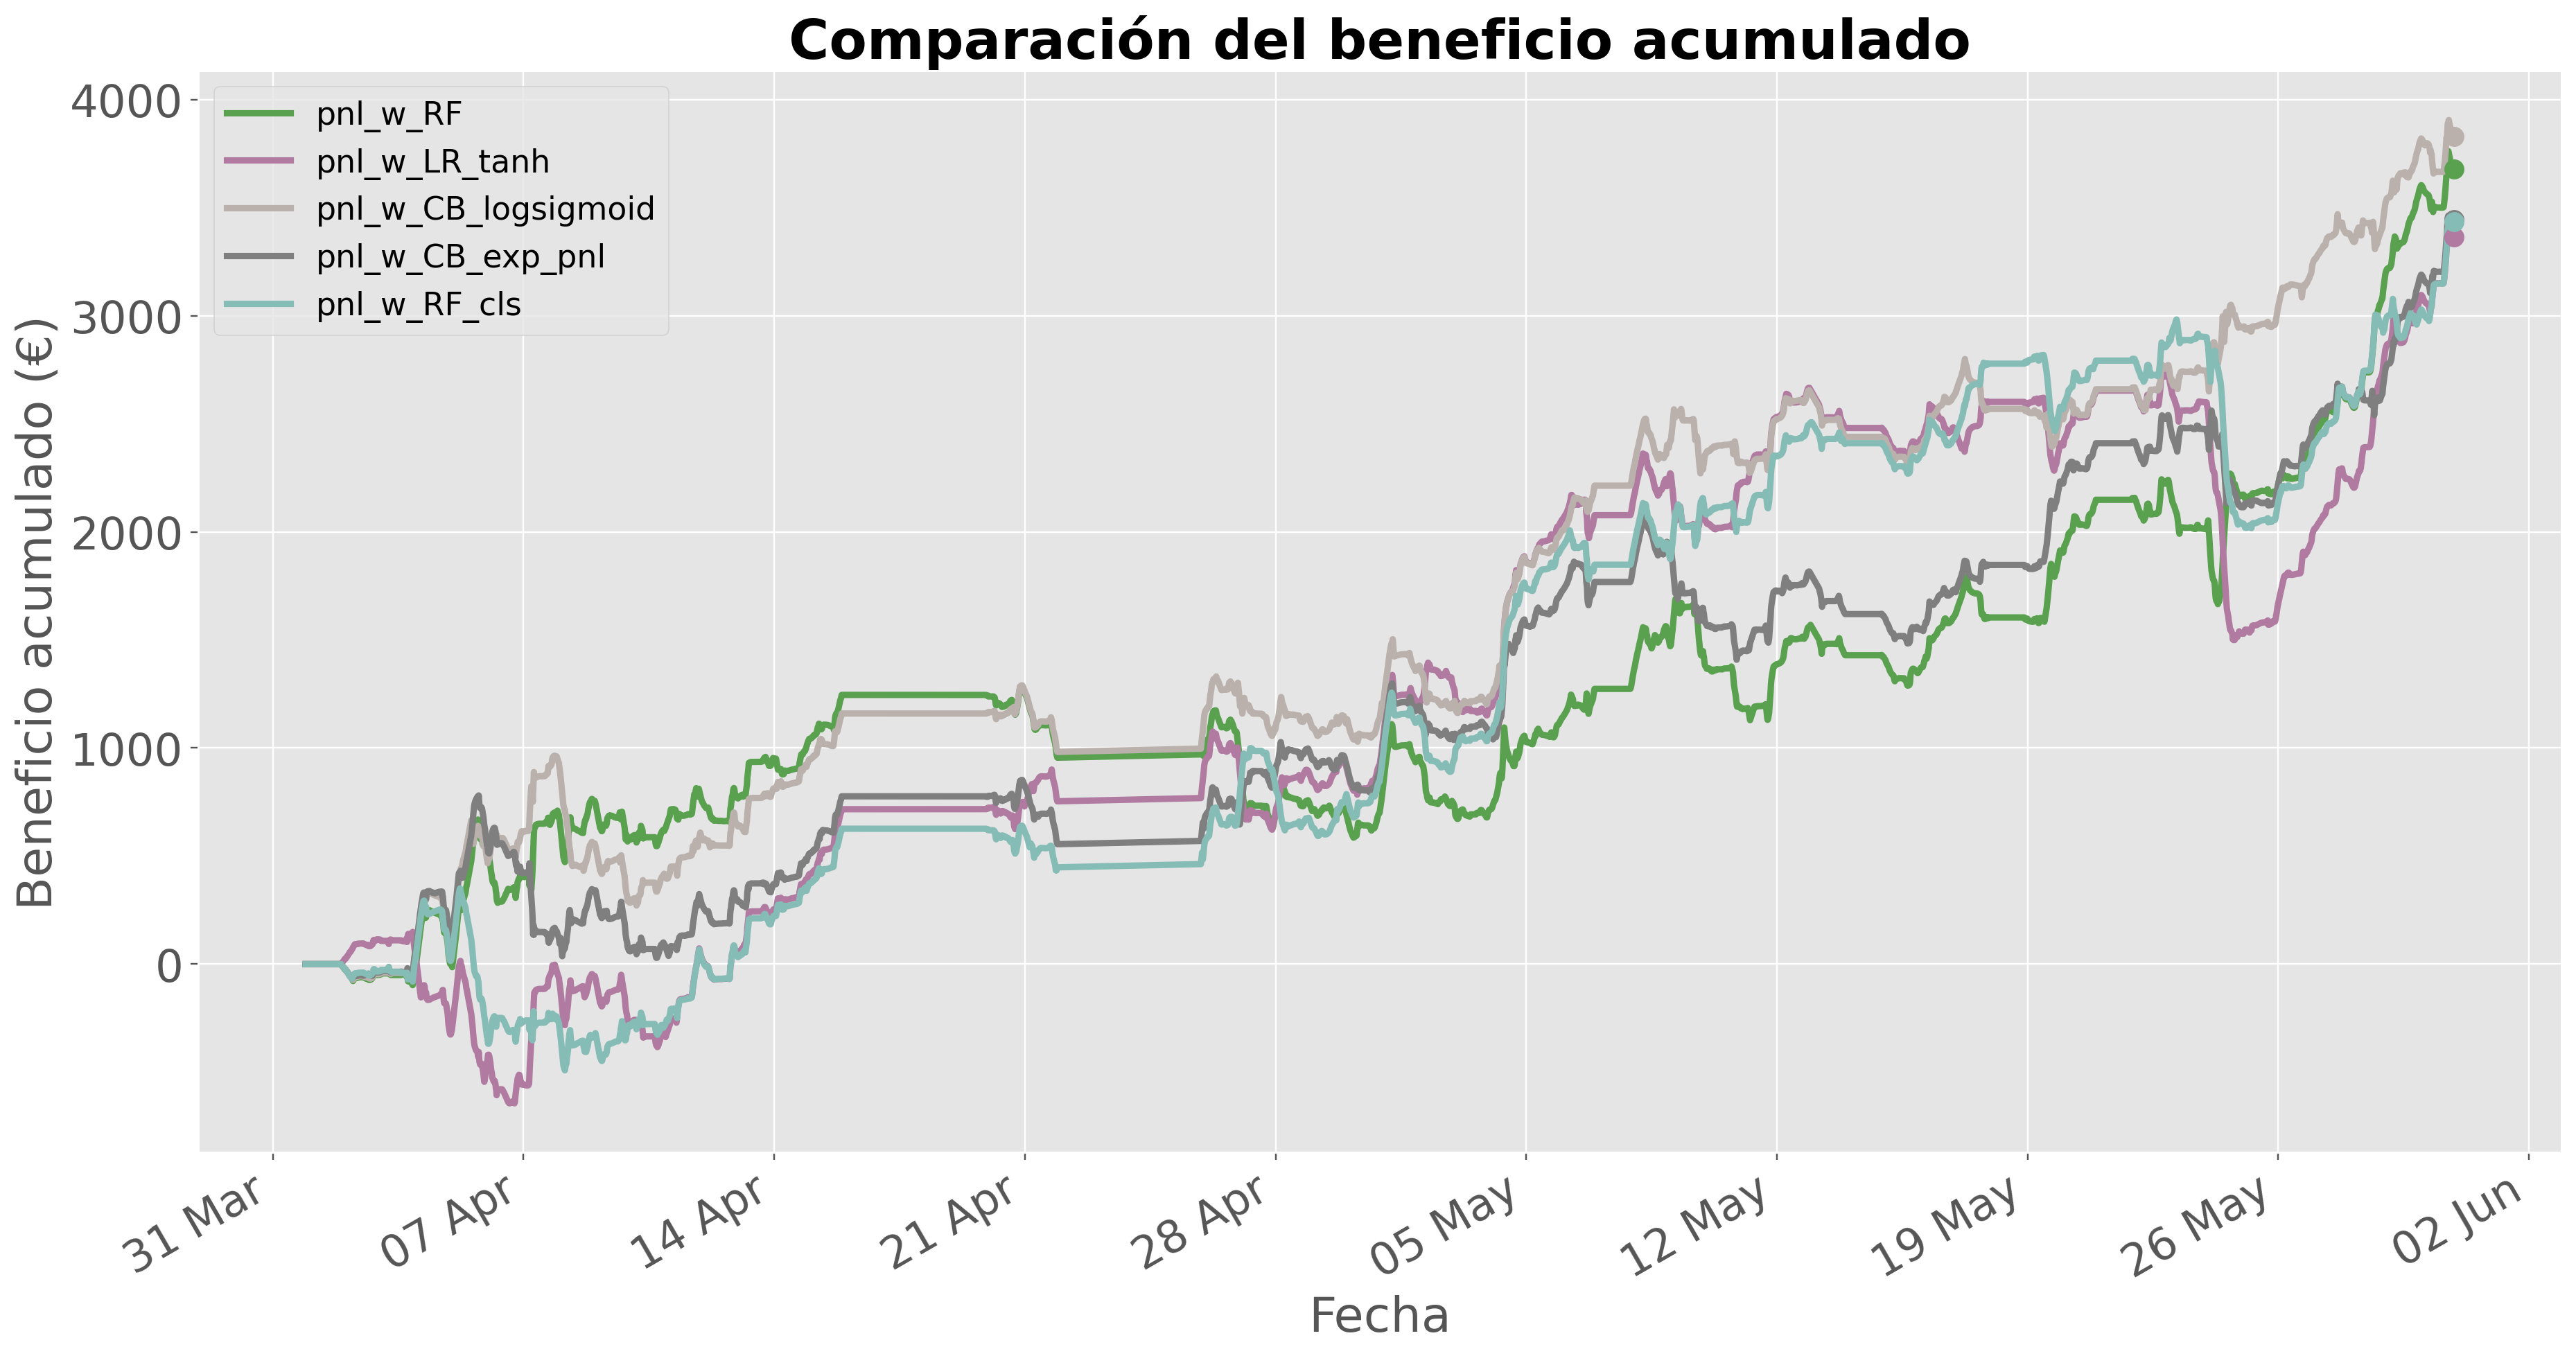

In [40]:
from plots import get_pnl_graph

colores = {
    # "pnl_w_Ridge": "#4E79A7",
    "pnl_w_RF": "#59A14F",
    # "pnl_w_CatBoost": "#9C755F",
    "pnl_w_LR_tanh": "#B07AA1",
    # "pnl_w_LR_logsigmoid": "#F28E2B",
    # "pnl_w_LR_exp_pnl": "#76B7B2",
    # "pnl_w_CB_tanh":  "#E15759",
    "pnl_w_CB_logsigmoid": "#BAB0AC",
    "pnl_w_CB_exp_pnl": "#7F7F7F",
    "pnl_w_RF_cls": "#86BCB6",
    # "pnl_w_spo": "#8C8C5A",
}

fig, ax = get_pnl_graph(df_results, colores, list(colores.keys()), save_path="pnl_acum_ida1_signo.png")

# plt.show()

In [14]:
pred_cols = [f"pred_{col}" for col in list(model_names_reg.keys())] + ["y_pred_spo"]

In [15]:
from func import get_metrics_regression, get_metrics_clasification
get_metrics_regression(df_results, tgt_col, pred_cols)

,Modelo,MAE,MSE,R2
0,pred_Ridge,5.118143,59.280109,-0.086197
1,pred_RF,4.994539,57.961328,-0.062033
2,pred_CatBoost,5.316147,61.601106,-0.128725
3,pred_LR_tanh,68.543370,7687.585323,-139.860665
4,pred_LR_logsigmoid,9.267695,138.887879,-1.544861
5,pred_LR_exp_pnl,7.543378,95.574858,-0.751231
6,pred_CB_tanh,10.214164,187.517644,-2.435911
7,pred_CB_logsigmoid,4.564590,63.923865,-0.171286
8,pred_CB_exp_pnl,4.501513,55.017493,-0.008093
9,y_pred_spo,79.416377,10620.507311,-193.600991


In [16]:
get_metrics_clasification(df_results, tgt_col, pred_cols + ["pred_RF_cls"])

,Modelo,Accuracy,Recall,Precision
0,pred_Ridge,0.558293,0.517106,0.736842
1,pred_RF,0.520633,0.426582,0.738470
2,pred_CatBoost,0.487580,0.365425,0.723188
3,pred_LR_tanh,0.651643,0.752952,0.729326
4,pred_LR_logsigmoid,0.637019,0.697850,0.739019
5,pred_LR_exp_pnl,0.634816,0.707539,0.731684
6,pred_CB_tanh,0.504607,0.591583,0.634828
7,pred_CB_logsigmoid,0.537260,0.447472,0.752929
8,pred_CB_exp_pnl,0.522236,0.449289,0.723902
9,y_pred_spo,0.514022,0.646382,0.629237


In [22]:
df =  pd.read_csv("./data/datos_TFM.csv")

## calculamos spreads
df.loc[:, "spread_ida1_spot"] = df["precio_spot_intradiario1_Espana"] - df["precio_spot_diario_Espana"]
df.loc[:, "spread_ida2_spot"] = df["precio_spot_intradiario2_Espana"] - df["precio_spot_diario_Espana"]
df.loc[:, "spread_ida3_spot"] = df["precio_spot_intradiario3_Espana"] - df["precio_spot_diario_Espana"]

C:\Users\Usuario\AppData\Local\Temp\ipykernel_10048\3440107918.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[:, "spread_ida1_spot"] = df["precio_spot_intradiario1_Espana"] - df["precio_spot_diario_Espana"]
C:\Users\Usuario\AppData\Local\Temp\ipykernel_10048\3440107918.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[:, "spread_ida2_spot"] = df["precio_spot_intradiario2_Espana"] - df["precio_spot_diario_Espana"]
C:\Users\Usuario\AppData\Local\Temp\ipykernel_10048\3440107918.py:6: PerformanceWarning: DataFra

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def boxplot_pnl(x1, x2, x3,
                labels=("Intradiario1 / Diario", "Intradiario2 / Diario", "Intradiario3 / Diario"),
                titulo="Boxplot variables objetivos",
                ylabel="(€)"):

    datos = [
        np.asarray(x1)[~np.isnan(x1)],
        np.asarray(x2)[~np.isnan(x2)],
        np.asarray(x3)[~np.isnan(x3)]
    ]

    fig, ax = plt.subplots(figsize=(17, 9))

    ax.boxplot(
        datos,
        tick_labels=labels,          # labels si tu matplotlib es antiguo
        patch_artist=True,
        widths=0.55,
        showmeans=True,
        showfliers=True,
        boxprops=dict(facecolor="#4E79A7", edgecolor="black", linewidth=1.5),
        whiskerprops=dict(color="black", linewidth=1.4),
        capprops=dict(color="black", linewidth=1.4),
        medianprops=dict(color="#E15759", linewidth=2.5),
        meanprops=dict(
            marker="D",
            markerfacecolor="gold",
            markeredgecolor="black",
            markersize=7
        ),
        flierprops=dict(
            marker="o",
            markersize=5,
            markerfacecolor="gray",
            markeredgecolor="black",
            alpha=0.6
        ),
    )

    ax.set_title(titulo, fontsize=15, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12)

    ax.grid(axis="y", linestyle="--", alpha=0.35)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    # plt.show()

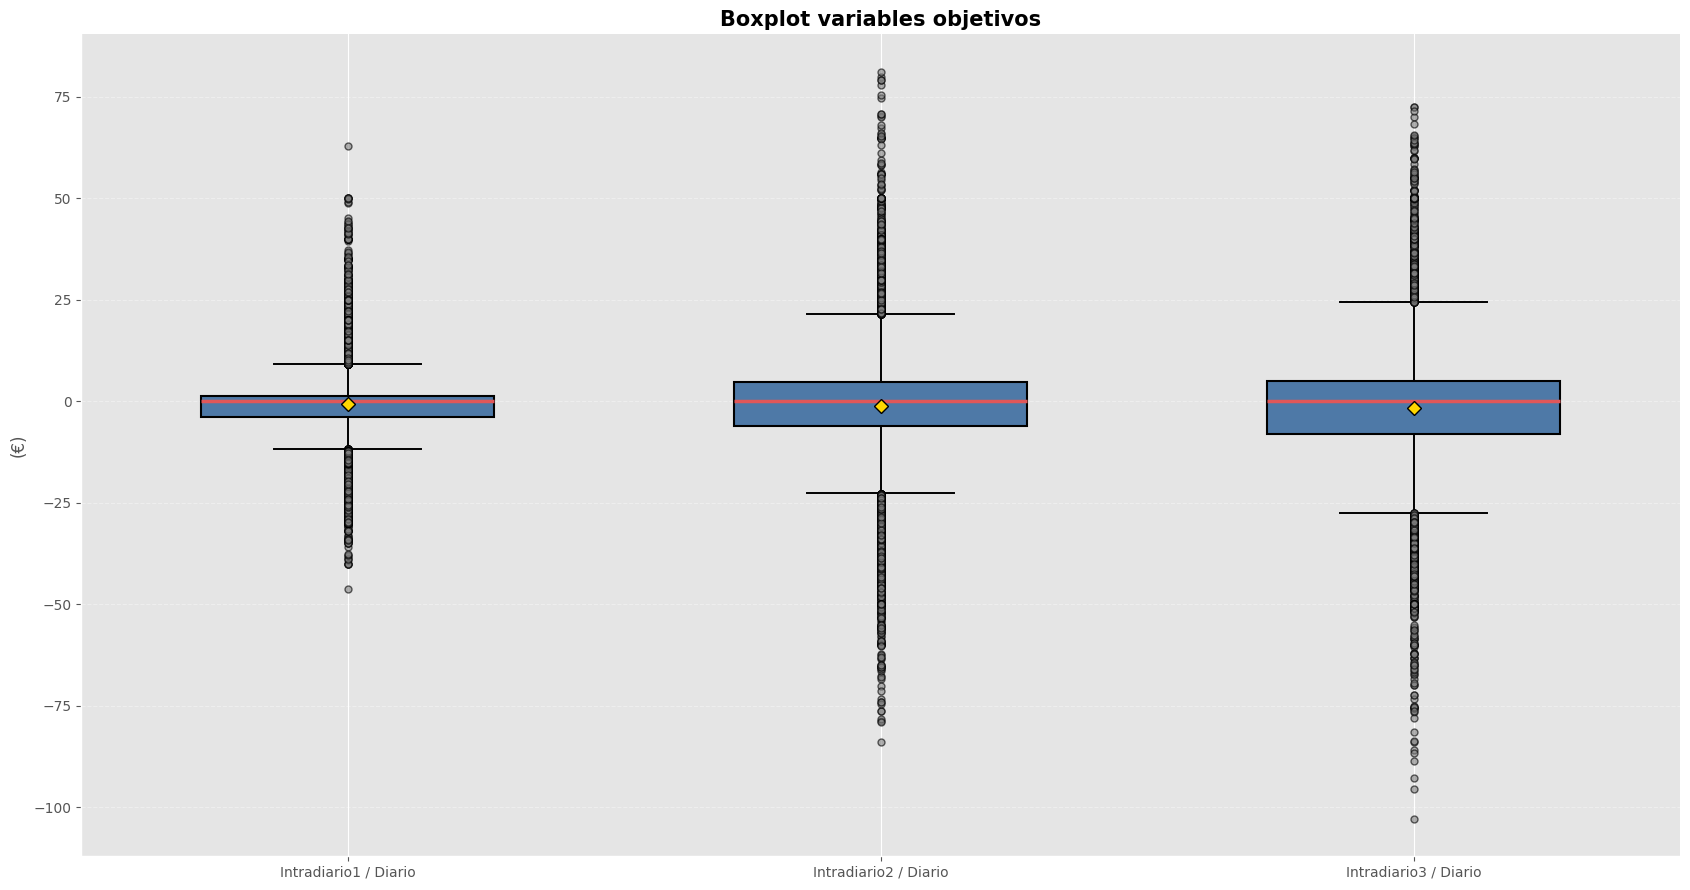

In [38]:
boxplot_pnl(df["spread_ida1_spot"], df["spread_ida2_spot"], df["spread_ida3_spot"])
plt.savefig(
            "boxplot_tgt.png",
            dpi=300,
            bbox_inches="tight"
        )

In [33]:
df["spread_ida1_spot"].var()

np.float64(63.887653513747814)

In [34]:
df["spread_ida2_spot"].var()

np.float64(180.73116421851134)

In [35]:
df["spread_ida3_spot"].var()

np.float64(257.2720338959765)